# Measurement Pipeline

In [1]:
# /// script
# requires-python = ">=3.10"
# dependencies = [
#     "matplotlib",
#     "numpy",
#     "scikit-image",
#     "scipy",
#     "tifffile",
#     "imagecodecs",
#     "pandas",
#     "seaborn",
#     "bobiac_tools @ git+https://github.com/bobiac/bobiac-tools.git"
# ]
# ///

## <mark style="color: black; background-color: rgb(127,196,125); padding: 3px; border-radius: 5px;">Overview</mark>

In this notebook, we will run through a full measurement pipeline. 

Our data are two images of cells stained with phalloidin (F-actin). One image is from an untreated control and one from a drug tretment.
Our question is: **Does the drug change F-actin abundance and/or cell size?**

To find out we will learn how to extract single cell properties using the [**scikit-image**](https://scikit-image.org/docs/stable/) library. Moreover, we will learn how to use the [**pandas**](https://pandas.pydata.org/docs/) library for data handling. Lastly we will brifly introduce [**seaborn**](https://seaborn.pydata.org/) for simple plotting and visualisation.



## <mark style="color: black; background-color: rgb(127,196,125); padding: 3px; border-radius: 5px;">Importing libraries</mark>

## <mark style="color: black; background-color: rgb(127,196,125); padding: 3px; border-radius: 5px;">Load and Display Image and Label Mask</mark>

First we load and display our control image and segmentation. We will walk through how to set up the measurements first and then apply the same strategy to the image of the drug treated cells.

We visualise the image and the segmentation with the overlay function. Hint: if you just want to plot the image use the overlay function with just the image.

Before we use the segmentation to measure, we need to remove all objects that touch the border, since they are likely not fully in the field of view and therefore not measurable.

As we learned before, the labeled mask is a picture the same size of the raw image that has **pixel value 0 for the background** and a **unique integer > 0 for each segmented object** this value we call an objects **index**.
Here, we plotted each segmented object in a different color together with its index.

We can directly access specific objects in our label mask by addressing them using their index.

This new image we obtained is a **boolean mask** with value `False` for background and `True` for the object with the index we specified.

To verify that this is indeed a binary mask, we can query for the minimum and maximum value using the `np.min()` and `np.max()` functions:


## <mark style="color: black; background-color: rgb(127,196,125); padding: 3px; border-radius: 5px;">Manual Extraction of Properties</mark>

Now we can use this mask to measure properties of the object such as its area or the fluorescence intensity of that region in the raw image (i.e. the intensity of the cell).

### <mark style="color: black; background-color: rgb(190,223,185); padding: 3px; border-radius: 5px;">Area measurement</mark>
To measure the area of the object we can make use of the fact that the boolean mask is `False` or `0` outside of the object and `True` or `1` inside it.

To convert the area in pixels to µm, we can multiply it with the squared `pixel size` in µm. Here we assume that one pixels has the size `0.325 µm`.

### <mark style="color: black; background-color: rgb(190,223,185); padding: 3px; border-radius: 5px;">Intensity measurement</mark>
To measure the objects intensity, we can use the boolean mask to index our raw image.

We can then calculate the **mean intensity** using the `np.mean()` function:

### <mark style="color: black; background-color: rgb(252,185,118); padding: 3px; border-radius: 5px;">✍️ Exercise: Measure area, basic intensity features for all nuclei in the dataset</mark>

In this exercise, we want to measure for each object in our segmentation mask its area, its mean intensity, the variabilty of its intensity (via standard deviation), and its minimum and maximum intensity values. For this, you can follow these steps:
1. Create an empty list for each feature (e.g. `area_list`).
2. Write a for loop that iterates over all object indices in the segmentation mask.
3. For each iteration measure all features (useful functions are `np.std`, `np.min`, `np.max`) and store them in the corresponding list.
4. Plot each feature as a histogram using `plt.hist`.

## <mark style="color: black; background-color: rgb(127,196,125); padding: 3px; border-radius: 5px;">Automated Extraction of Properties</mark>

The [`skimage.measure`](https://scikit-image.org/docs/stable/api/skimage.measure.html) module from **scikit-image** provides efficient tools for measuring properties of labeled image regions, extracting both morphological and intensity-based features for every object in a single call.

A central function in this module is [`regionprops_table`](https://scikit-image.org/docs/stable/api/skimage.measure.html#skimage.measure.regionprops_table):

**Parameters:**
- `label_image` — A 2D or 3D integer array where each unique non-zero value identifies a distinct object.
- `intensity_image` *(optional)* — The corresponding grayscale image, required for intensity-based measurements.
- `properties` — A list of property names to measure and compute. 

For example:

```python
skimage.measure.regionprops_table(label_image, intensity_image=image, properties=["area", "intensity_mean"])
```

**Returns:**
- A `dict` mapping each property name to an array of values, one per labeled object.

The table below summarizes commonly used properties:

| Measurement | Description |
|-------------|-------------|
| area | Number of pixels in the object (size) |
| perimeter | Approximate boundary length |
| eccentricity | Elongation of the shape (0 = circle, 1 = line segment) |
| solidity | Ratio of object area to its convex hull area |
| orientation | Angle of the major axis relative to the horizontal |
| intensity_mean | Mean pixel intensity within the region |
| intensity_std | Standard deviation of pixel intensities within the region |
| intensity_max | Maximum pixel intensity within the region |
| intensity_min | Minimum pixel intensity within the region |
| image_intensity | Pixel values cropped to the object's bounding box |
| centroid | Center of mass coordinates |
| bbox | Bounding box coordinates |
| coords | List of coordinates of all pixels (y, x) |

A full list of all measurable properties can be found in the [regionprops documentation](https://scikit-image.org/docs/stable/api/skimage.measure.html#skimage.measure.regionprops).

Use `regionprops_table` to extract measurements from `labeled_mask` and `image`:

`regionprops_table` creates a dictionary where the keys are the names of the properties and the values are numpy arrays of the measurements of the properties for all objects in the label mask. We can access all area measurements like this: `props['area']` and an object-specific area measurement like this: `props['area'][index]` with `index` being e.g. `0` for the first object. The order of objects is the same across all property arrays.

As you can see, we get the same area value we obtained manually before.

### <mark style="color: black; background-color: rgb(252,185,118); padding: 3px; border-radius: 5px;">✍️ Exercise: Use `regionprops_table` to measure basic features of all nuclei</mark>

In this exercise, we repeat the exercise above using `regionprops_table` instead of looping over each object.
Measure `area`, `intensity_mean`, `intensity_std`, `intensity_max`, `intensity_min`, and (this one is new) `perimeter`.
For that you can:
1. Use regionprops with the appropriate properties.
2. Use `plt.hist` to plot a histogram for each property. (You can use a for loop for that if you want to be efficient.)

Note how much less code you have to write compared with the previous exercise.

Bonus: think about how you would implement the `perimeter` property manually. 

## <mark style="color: black; background-color: rgb(127,196,125); padding: 3px; border-radius: 5px;">Tables -> `pandas.DataFrame`</mark>
Using `lists`, `dictionaries` and `np.arrays` for data analysis works fine, but is a little bit clunky. Here, we introduce a more streamlined and straightforward method for storing and accessing your data. We use the `pandas` package which is centred around the `DataFrame` object, an intuitive 2D table that allows basic plotting, labelling of rows, columns and conditional indexing as well as table operations such as `melt` and `pivot` and summary statistics like `mean` or `std`. 

This is a brief interlude before we return to comparing our control and drug treated cells. It will be worth it in the end.

We start by importing `pandas` and creating a new `DataFrame` variable.

Note how tidy this format is. Individual cells are `rows` containing all measuremnt that relate to that cell and `columns` are sets of measurements for all cells.

### <mark style="color: black; background-color: rgb(190,223,185); padding: 3px; border-radius: 5px;">Accessing data in `DataFrames`</mark>
Accessing columns works similar to dictionaries: `df[column]` or `df[[list_of_columns]]`.

Accessing rows can be done via `index` using `.iloc` or by condition using `.loc`.

First we can access all the properties of the previously selected cell `42`.

We can index conditionally based on properties. Here we select all cells with an area larger than 3000 pixels.

To fully understand what happened there, we break this line into parts.

A variety of different logical operations can be used for **conditional indexing** via `.loc`.
Those include: `<`, `>`, `<=`, `>=`, `==`, `!=` (not equal to), `.isin(list)` (equal to any object in list), `~` (not). Morover, multiple conditions can be chained using `&` (and), `|` (or) operators (each condition has to be in `()` parenthesis for this). Visit the excellent [pandas tutorial](https://pandas.pydata.org/docs/getting_started/intro_tutorials/03_subset_data.html) on selecting subsets from DataFrames for more details.

Note that if no criterion in `.loc` is met, we get an `Empty DataFrame`.

### <mark style="color: black; background-color: rgb(252,185,118); padding: 3px; border-radius: 5px;">✍️ Exercise: Use `iloc` and `loc` to access specific measurements in the `DataFrame`</mark>

In this exercise, use the `iloc` and `loc` indexers to access specific entries of `df`.
1. Print only the first ten rows.
2. Print all rows where the `perimeter` is smaller than 140 pixels.
3. Print all rows where the `area` is smaller than 1500 pixesl or the `minimum intensity` exceeds 0.08.
4. BONUS: Print the `area` of all rows where `instensity_std` is less than 100.

### <mark style="color: black; background-color: rgb(190,223,185); padding: 3px; border-radius: 5px;">Create new columns and math on columns</mark>
The `DataFrame` format allows us to do calculations using whole columns and to save the results in new columns. This is very useful for doing calculations on the raw measurements.

Let's measure the background intensity and subtract it from the mean intensity of all objects

Note how intuitive this syntax is. We can also do calculations using multiple rows of the DataFrame.

Let's calculate the difference between the maximum and minimum intensity for each object and store it in a new column called `intensity_range`.

### <mark style="color: black; background-color: rgb(252,185,118); padding: 3px; border-radius: 5px;">✍️ Exercise: Create a couple of new columns</mark>

1. Create a column called `cell_id` containing integer values that correspond to the value of the object in the label mask.
2. Create a column called `sum_intensity` that contains the sum of all pixel intensities (mean intensity * number of pixels).
3. BONUS: Create a column called `circularity` that is 1 if an object is perfectly circular and goes towards 0 otherwise.

### <mark style="color: black; background-color: rgb(190,223,185); padding: 3px; border-radius: 5px;">Numerical and categorical values</mark>
So far we have only used numerical values in our `DataFrame` such as `area` (which is expressed as a number). However, in `pandas` (and data analysis generally) we may also use categorical values. Examples are classified gene expression (`expressing`) which could be `none`, `low`, `high` or experimental conditions like `condition` which may be `control`,  `drug`.

First we create a new column called `image_id` that contains the same value for all rows, which is the name of the image we analyzed.

This might look redundant, but will be very important when analysing multiple images and a key part of keeping track of the source of data. With this notation, `cell_id` and `image_id` combined can identify every object across a whole dataset of however many images.

Let's classify area into three categories: small (< 4000 pixels), medium (4000-8000 pixels), and large (> 8000 pixels) and store this in a new column called `size_category`

Next, we classify intensity_mean into three categories: low, medium, and high, and store the category in a new column called `expression`.

### <mark style="color: black; background-color: rgb(252,185,118); padding: 3px; border-radius: 5px;">✍️ Exercise: Create some categorical columns</mark>
1. Make a new column called `condition` and assign it the value `control`.
2. Classify `intensity_sum` into `low` and `high` using the threshold `400` and store the classification in a column called `sum_classified`.
3. BONUS: classify the circularity of the objects into three classes. Think about what would be meaningful thresholds.

## <mark style="color: black; background-color: rgb(127,196,125); padding: 3px; border-radius: 5px;">Overlay measurements on the image</mark>
For quality control or exploration it is important to overlay measured quantities on the original image. Here we use the `overlay` function for that.

### <mark style="color: black; background-color: rgb(190,223,185); padding: 3px; border-radius: 5px;">Calculate summary statistics and correlation</mark>
Pandas gives us the ability to very effectively compute common summary statistics like mean, median, standard deviation, standard error, etc. on either whole columns or on subsets via aggregation (split by a categorical variable).

This is a table of common statistics that can be used either as e.g. `df['area'].mean()` or `df['area'].agg(['mean'])`.

| Function | Description |
|----------|-------------|
| count | Number of non-NA observations |
| value_counts | Number of observations per category |
| sum | Sum of values |
| mean | Mean of values |
| median | Arithmetic median of values |
| min | Minimum |
| max | Maximum |
| std | Bessel-corrected sample standard deviation |
| var | Unbiased variance |
| sem | Standard error of the mean |
| skew | Sample skewness (3rd moment) |
| kurt | Sample kurtosis (4th moment) |

We can group (aggregate) the data by categories and calculate summary statistics on each group. This is very useful if we e.g. want to find out if cells that have received a treatment are expressing upregulate a gene or exhibit morphological differences.

We achieve this by using the `.groupby()` method.

First, let's group objects by size category (small, medium, large) based on `size_category` and calculate the average `intensity_mean` for each size category.

We can also group by multiple categories at once. Here we group by `size_category` and `expression` and we evaluate the mean circularity. 

The `NaN` above indicate that there exist no observation with that combination of categories.

Another very useful statistic to calculate is the correlation between two columns per observation. For this we can use the `.corr()` method.

### <mark style="color: black; background-color: rgb(190,223,185); padding: 3px; border-radius: 5px;">Combine data from multiple `DataFrames`</mark>
To combine data, e.g. from multiple images or experimental days, it is often necessary to combine dataframes. While this is straightforward, it is important to pay attention to proper 'book keeping' because it is easy to lose track of where data comes from and what conditions are associated with it. 

Here we will load the mask and image of the drug treated condition, and measure properties using `regionprops_table`. We then combine it with our exiting dataframe.

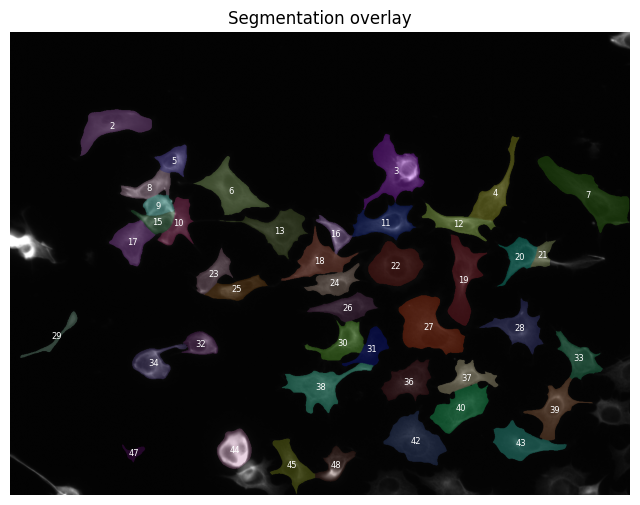

(<Figure size 800x800 with 1 Axes>,
 <Axes: title={'center': 'Segmentation overlay'}>)

In [47]:
overlay_labels(image_2, labeled_mask_2)

Now it is absolutely necessary to add a column that identifies where the data came from. In this case we (like above) use the image name as identifier.

Now we can use the `concat` function in pandas to create a merged dataframe from the first and second ones.

There are lot's of `NaN` values in the lower part of the dataframe. Those correspond to entries that we have computed in the first dataframe but not the second.
To avoid this, we can use the parameter `join` and set it to `inner`. This way only columns that exist in both dataframes will be kept. `outer` retains all columns from both dataframes as we have seen above.

Now we don't have any `NaN`s anymore. But we have also lost all the new columns we generated on the first dataframe. It is therefore generally advised to merge dataframes before doing calculations or classifications or to perform them in parallel on all dataframes using e.g. a for loop.

### <mark style="color: black; background-color: rgb(190,223,185); padding: 3px; border-radius: 5px;">Handle strings in DataFrames</mark>
It is often very handy to manipulate strings in a dataframe column. Especially when files are consistently named, this can save a lot of effort when categorising data.

For example: our images are called `F01_202w1` and `F02_92w1`. Say, `F01` would be the well with the control and `F02` is the well with a drug. We can use the `image_id` column to create a new column with those labels.

For that we can use the `.str` method on the `image_id` column, which allows us to do string operations like `split` in bulk.

### <mark style="color: black; background-color: rgb(190,223,185); padding: 3px; border-radius: 5px;">Saving DataFrames as CSV</mark>
A key advantage of the DataFrame is that it can be stored as a CSV (comma separated values) file that can be opened in Excel, Prism, R or any other data analysis software.

For that we simply use the `.to_csv` method on a DataFrame.

To load a CSV file into a Dataframe, we use the `read_csv` function.

### <mark style="color: black; background-color: rgb(190,223,185); padding: 3px; border-radius: 5px;">Concluding remarks on `pandas`</mark>

This is only a brief overview of the capabilities of pandas. 

There are several great resources that go deeper. Check out the [pandas tutorials](https://pandas.pydata.org/docs/getting_started/intro_tutorials/index.html) or [community tutorials](https://pandas.pydata.org/docs/getting_started/tutorials.html).

## <mark style="color: black; background-color: rgb(127,196,125); padding: 3px; border-radius: 5px;">Success</mark>
Now we have a tidy table that contains all cells of the control and drug treated conditions and their corresponding properties, including `area` and `intensity_mean`. This will allow us to make a statement about the effect of the drug and maybe answer our question, which was: **Do drug treated cells exhibit changes in F-actin abundance or size?**

## <mark style="color: black; background-color: rgb(127,196,125); padding: 3px; border-radius: 5px;">Plotting results with `seaborn`</mark>
To plot results contained in a DataFrame, we can use the `seaborn` plotting library which is based on `matplotlib` and allows for straightforward usage of categorical and numerical data and gives access to standard plots like **bar graphs**, **violin plots**, **histograms**, **heatmaps**, **line plots**, **regression plots**, etc. See the [seaborn gallery](https://seaborn.pydata.org/examples/index.html) for inspiration.

### <mark style="color: black; background-color: rgb(190,223,185); padding: 3px; border-radius: 5px;">Histogram</mark>
A great tool for looking at distributions of values. Here we use the `histplot` function. Unlike in matplotlib we do not hand lists or arrays to the `x` (and `y`) parameters; instead we specify a DataFrame as `data` and assign columns as `x` (and later `y`).

### <mark style="color: black; background-color: rgb(190,223,185); padding: 3px; border-radius: 5px;">Box plot</mark>
One common way of displaying results is as a box plot. Here we use the `boxplot` function to create one. 

### <mark style="color: black; background-color: rgb(190,223,185); padding: 3px; border-radius: 5px;">Violin plot</mark>
To generate a violin plot we use the `violinplot` function. Note that the arguments of the plotting function are conserved between `violinplot` and `boxplot`. This is the case for most seaborn plotting functions. Moreover, since seaborn is using matplotlib, we can use matplotlib commands to adjust the figure. Here we add a grid and change the axis labels.

### <mark style="color: black; background-color: rgb(190,223,185); padding: 3px; border-radius: 5px;">Bar graph</mark>
The seaborn function for that is `barplot` and it follows the same pattern as the two previous plots. Here we demonstrate another very useful function of seaborn plots which is splitting data by a second category. 

Say, we would like to explore the difference in expression between the control and drug is driven by higher expression only in small cells. After generating size categories based on their area, we can use the `hue` parameter to split each condition into several bars. This of course also works for the plots above.

### <mark style="color: black; background-color: rgb(190,223,185); padding: 3px; border-radius: 5px;">Scatter plot</mark>
To plot two continuous variables against each other we can use `scatterplot`.

### <mark style="color: black; background-color: rgb(252,185,118); padding: 3px; border-radius: 5px;">✍️ Exercise: Plot the results for area changes</mark>
1. Create a violinplot that shows the differences in cell size between control and drug treatment.
2. Classify `intensity_mean` into `low` and `high` using the threshold `750` and plot `area` by `condition` split by this classification.
3. Create `swarmplot`s for `area` by `condition` and `intensity_mean` by `condition`. Look up `swarmplot` in the seaborn documentation.

## <mark style="color: black; background-color: rgb(127,196,125); padding: 3px; border-radius: 5px;">Bringing it all together - batch processing</mark>
To process more than a hand full of images, we can automate the measurement process. 

## <mark style="color: black; background-color: rgb(127,196,125); padding: 3px; border-radius: 5px;">Conclusion</mark>
We successfully measured properties of cells and compared them with each other. In the following notebooks we will explore two common types of analysis: nested measurements and time series data. Now that we know `regionprops_table`, `pandas` and `seaborn` this will be relatively straightforward.